Cell 1: Environment Setup and Imports


In [1]:
# ============================================================================
# Cell 1: Install Dependencies and Import Libraries
# ============================================================================

# Install required packages (uncomment if needed)
# !pip install torch torchvision timm wandb matplotlib seaborn pandas
# !pip install git+https://github.com/ildoonet/pytorch-randaugment.git

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as transforms

# For experiment tracking (optional but recommended)
try:
    import wandb
    WANDB_AVAILABLE = True
except:
    WANDB_AVAILABLE = False
    print("W&B not available. Using local logging only.")

# Set random seeds for reproducibility
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


W&B not available. Using local logging only.
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version: 12.1
Available GPU Memory: 4.29 GB


Cell 2: Configuration and Hyperparameters


In [2]:
# ============================================================================
# Cell 2: Experimental Configuration (Based on FixMatch Paper)
# ============================================================================

class Config:
    """Configuration class containing all hyperparameters based on FixMatch paper"""
    
    def __init__(self, dataset_name='cifar10', num_labels=40):
        self.dataset_name = dataset_name
        self.num_labels = num_labels
        
        # Dataset-specific configurations
        self.dataset_configs = {
            'cifar10': {
                'num_classes': 10,
                'img_size': 32,
                'model': 'wrn-28-2',  # Wide ResNet-28-2 (1.5M params) @17
                'weight_decay': 5e-4,  # @17
                'train_size': 50000,
                'test_size': 10000,
            },
            'cifar100': {
                'num_classes': 100,
                'img_size': 32,
                'model': 'wrn-28-8',  # Wide ResNet-28-8 for CIFAR-100 @17
                'weight_decay': 1e-3,  # @17
                'train_size': 50000,
                'test_size': 10000,
            },
            'svhn': {
                'num_classes': 10,
                'img_size': 32,
                'model': 'wrn-28-2',  # @17
                'weight_decay': 5e-4,  # @17
                'train_size': 73257,
                'test_size': 26032,
                'extra_size': 531131,
            },
            'stl10': {
                'num_classes': 10,
                'img_size': 96,
                'model': 'wrn-37-2',  # Wide ResNet-37-2 (5.9M params) @17, @23
                'weight_decay': 5e-4,  # @17
                'train_size': 5000,
                'test_size': 8000,
                'unlabeled_size': 100000,
            }
        }
        
        # Get dataset-specific config
        self.ds_config = self.dataset_configs[dataset_name]
        self.num_classes = self.ds_config['num_classes']
        self.img_size = self.ds_config['img_size']
        self.model_name = self.ds_config['model']
        
        # FixMatch hyperparameters from paper @2, @17
        self.tau = 0.95  # Confidence threshold @2, @7
        self.mu = 7  # Ratio of unlabeled to labeled batch size @17
        self.lambda_u = 1.0  # Unsupervised loss weight @17
        self.T = 1.0  # Temperature for sharpening (not used in FixMatch)
        
        # Training hyperparameters @17, @79, @80
        self.batch_size = 64  # Labeled batch size @17
        self.lr = 0.03  # Initial learning rate @17, @79
        self.momentum = 0.9  # SGD momentum @17, @79
        self.weight_decay = self.ds_config['weight_decay']
        self.nesterov = True  # Use Nesterov momentum
        self.ema_decay = 0.999  # Exponential moving average decay @17
        
        # Learning rate schedule @17, @79, @80
        self.total_steps = 2**20  # 1,048,576 iterations (1024 epochs) @17
        self.lr_schedule = 'cosine'  # Cosine decay @17, @79
        
        # Evaluation
        self.eval_step = 1024  # Evaluate every 1024 iterations
        self.num_eval_iter = None  # Use full test set
        
        # Augmentation
        self.strong_augment = 'randaugment'  # or 'ctaugment' @16
        self.randaugment_n = 2  # Number of augmentation transformations
        self.randaugment_m = 10  # Magnitude of augmentations
        
        # Paths
        self.data_root = './data'
        self.output_dir = f'./experiments/{dataset_name}_{num_labels}labels'
        self.checkpoint_dir = os.path.join(self.output_dir, 'checkpoints')
        
        # Create directories
        os.makedirs(self.data_root, exist_ok=True)
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        
        # Experiment tracking
        self.use_wandb = WANDB_AVAILABLE
        self.exp_name = f'FixMatch_{dataset_name}_{num_labels}labels'
        
        # Computational profiling
        self.profile_memory = True
        self.profile_time = True
        
    def __repr__(self):
        return f"Config(dataset={self.dataset_name}, labels={self.num_labels}, model={self.model_name})"

# Initialize configurations for all experimental settings
configs = {
    # Tier 1: Ultra-low label regime
    'cifar10_40': Config('cifar10', 40),
    'cifar100_400': Config('cifar100', 400),
    'svhn_40': Config('svhn', 40),
    'stl10_40': Config('stl10', 40),
    
    # Tier 2: Standard benchmark
    'cifar10_250': Config('cifar10', 250),
    'cifar100_2500': Config('cifar100', 2500),
    'svhn_250': Config('svhn', 250),
    'stl10_1000': Config('stl10', 1000),
    
    # Tier 3: Moderate labels
    'cifar10_4000': Config('cifar10', 4000),
    'cifar100_10000': Config('cifar100', 10000),
    'svhn_1000': Config('svhn', 1000),
}

# Display configurations
print("\n=== Experimental Configurations ===")
for name, cfg in configs.items():
    print(f"{name}: {cfg}")



=== Experimental Configurations ===
cifar10_40: Config(dataset=cifar10, labels=40, model=wrn-28-2)
cifar100_400: Config(dataset=cifar100, labels=400, model=wrn-28-8)
svhn_40: Config(dataset=svhn, labels=40, model=wrn-28-2)
stl10_40: Config(dataset=stl10, labels=40, model=wrn-37-2)
cifar10_250: Config(dataset=cifar10, labels=250, model=wrn-28-2)
cifar100_2500: Config(dataset=cifar100, labels=2500, model=wrn-28-8)
svhn_250: Config(dataset=svhn, labels=250, model=wrn-28-2)
stl10_1000: Config(dataset=stl10, labels=1000, model=wrn-37-2)
cifar10_4000: Config(dataset=cifar10, labels=4000, model=wrn-28-2)
cifar100_10000: Config(dataset=cifar100, labels=10000, model=wrn-28-8)
svhn_1000: Config(dataset=svhn, labels=1000, model=wrn-28-2)


Cell 3: Data Augmentation Strategies


Using PyTorch's native RandAugment (torchvision)
torchvision version: 0.17.2+cu121

Testing Augmentation Transforms
Files already downloaded and verified
 Transforms created successfully!
  Weak augment output: torch.Size([3, 32, 32])
  Strong augment output: torch.Size([3, 32, 32])
  Test transform output: torch.Size([3, 32, 32])

Generating augmentation visualization...
Files already downloaded and verified


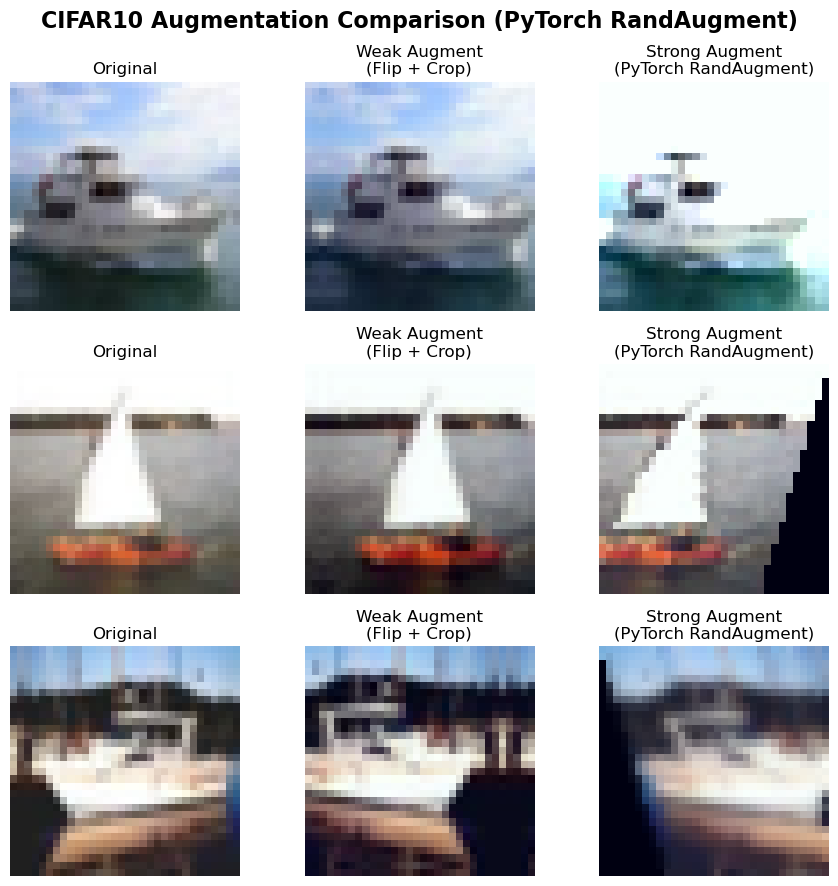

Saved visualization to: augmentation_comparison_cifar10.png

 Cell 3 completed successfully!


In [3]:
# ============================================================================
# Cell 3: Weak and Strong Augmentation (FixMatch Style) - FIXED VERSION
# ============================================================================

import torchvision.transforms as transforms
from torchvision.transforms import RandAugment  # Built-in PyTorch!

print("Using PyTorch's native RandAugment (torchvision)")
print(f"torchvision version: {torchvision.__version__}")

class WeakAugment:
    """
    Weak augmentation: Standard flip-and-shift strategy
    From FixMatch paper: "randomly flip images horizontally with 50% probability 
    and randomly translate by up to 12.5%"
    """
    def __init__(self, img_size=32, dataset='cifar10'):
        self.dataset = dataset
        transforms_list = []
        
        # Random horizontal flip (except SVHN)
        if dataset != 'svhn':
            transforms_list.append(transforms.RandomHorizontalFlip(p=0.5))
        
        # Random translation: up to 12.5% (4 pixels for 32x32 images)
        padding = int(img_size * 0.125)  # 12.5% padding
        transforms_list.extend([
            transforms.RandomCrop(img_size, padding=padding, padding_mode='reflect'),
            transforms.ToTensor(),
        ])
        
        # Normalization (standard for CIFAR/SVHN)
        if 'cifar' in dataset.lower():
            transforms_list.append(
                transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                   std=[0.2471, 0.2435, 0.2616])
            )
        elif dataset == 'svhn':
            transforms_list.append(
                transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                   std=[0.5, 0.5, 0.5])
            )
        elif dataset == 'stl10':
            transforms_list.append(
                transforms.Normalize(mean=[0.4467, 0.4398, 0.4066],
                                   std=[0.2603, 0.2566, 0.2713])
            )
        
        self.transform = transforms.Compose(transforms_list)
    
    def __call__(self, img):
        return self.transform(img)


class StrongAugment:
    """
    Strong augmentation using PyTorch's native RandAugment
    From FixMatch paper: "RandAugment for strong augmentation"
    
    PyTorch RandAugment parameters:
    - num_ops: Number of augmentation transformations to apply sequentially
    - magnitude: Magnitude for all operations (0-9 scale, but PyTorch uses 0-30 internally)
    """
    def __init__(self, img_size=32, dataset='cifar10', n=2, m=10):
        """
        Args:
            n: Number of augmentation transformations to apply (default: 2)
            m: Magnitude of augmentations (0-10 scale, will be converted to PyTorch's 0-30)
        """
        transforms_list = []
        
        # Random horizontal flip (except SVHN)
        if dataset != 'svhn':
            transforms_list.append(transforms.RandomHorizontalFlip(p=0.5))
        
        # PyTorch's RandAugment
        # Note: PyTorch uses magnitude scale 0-30, so we scale our m (0-10) to PyTorch's scale
        pytorch_magnitude = int(m * 3)  # Convert 0-10 to 0-30
        transforms_list.append(
            RandAugment(num_ops=n, magnitude=pytorch_magnitude)
        )
        
        transforms_list.append(transforms.ToTensor())
        
        # Normalization
        if 'cifar' in dataset.lower():
            transforms_list.append(
                transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                   std=[0.2471, 0.2435, 0.2616])
            )
        elif dataset == 'svhn':
            transforms_list.append(
                transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                   std=[0.5, 0.5, 0.5])
            )
        elif dataset == 'stl10':
            transforms_list.append(
                transforms.Normalize(mean=[0.4467, 0.4398, 0.4066],
                                   std=[0.2603, 0.2566, 0.2713])
            )
        
        self.transform = transforms.Compose(transforms_list)
    
    def __call__(self, img):
        return self.transform(img)


class TestTransform:
    """Standard test-time augmentation (normalization only)"""
    def __init__(self, img_size=32, dataset='cifar10'):
        transforms_list = [transforms.ToTensor()]
        
        # Normalization
        if 'cifar' in dataset.lower():
            transforms_list.append(
                transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                   std=[0.2471, 0.2435, 0.2616])
            )
        elif dataset == 'svhn':
            transforms_list.append(
                transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                   std=[0.5, 0.5, 0.5])
            )
        elif dataset == 'stl10':
            transforms_list.append(
                transforms.Normalize(mean=[0.4467, 0.4398, 0.4066],
                                   std=[0.2603, 0.2566, 0.2713])
            )
        
        self.transform = transforms.Compose(transforms_list)
    
    def __call__(self, img):
        return self.transform(img)


# ============================================================================
# Test Augmentations
# ============================================================================

def visualize_augmentations(dataset_name='cifar10', num_samples=3):
    """Visualize weak vs strong augmentations"""
    import matplotlib.pyplot as plt
    
    # Load a sample image
    if dataset_name == 'cifar10':
        dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
    elif dataset_name == 'cifar100':
        dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
    elif dataset_name == 'svhn':
        dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True)
    elif dataset_name == 'stl10':
        dataset = torchvision.datasets.STL10(root='./data', split='train', download=True)
    
    img_size = 32 if dataset_name != 'stl10' else 96
    weak_aug = WeakAugment(img_size, dataset_name)
    strong_aug = StrongAugment(img_size, dataset_name, n=2, m=10)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3*num_samples))
    fig.suptitle(f'{dataset_name.upper()} Augmentation Comparison (PyTorch RandAugment)', 
                 fontsize=16, fontweight='bold')
    
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        
        if dataset_name == 'svhn':
            img = dataset.data[idx].transpose(1, 2, 0)
        else:
            img, _ = dataset[idx]
        
        # Original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original', fontsize=12)
        axes[i, 0].axis('off')
        
        # Weak augmentation
        weak_img = weak_aug(img).permute(1, 2, 0).numpy()
        weak_img = (weak_img - weak_img.min()) / (weak_img.max() - weak_img.min())
        axes[i, 1].imshow(weak_img)
        axes[i, 1].set_title('Weak Augment\n(Flip + Crop)', fontsize=12)
        axes[i, 1].axis('off')
        
        # Strong augmentation
        strong_img = strong_aug(img).permute(1, 2, 0).numpy()
        strong_img = (strong_img - strong_img.min()) / (strong_img.max() - strong_img.min())
        axes[i, 2].imshow(strong_img)
        axes[i, 2].set_title('Strong Augment\n(PyTorch RandAugment)', fontsize=12)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'augmentation_comparison_{dataset_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved visualization to: augmentation_comparison_{dataset_name}.png")


# Test the transforms
print("\n" + "="*80)
print("Testing Augmentation Transforms")
print("="*80)

try:
    # Create transform instances
    weak_aug = WeakAugment(32, 'cifar10')
    strong_aug = StrongAugment(32, 'cifar10', n=2, m=10)
    test_aug = TestTransform(32, 'cifar10')
    
    # Load a test image
    dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
    test_img, _ = dataset[0]
    
    # Apply transforms
    weak_result = weak_aug(test_img)
    strong_result = strong_aug(test_img)
    test_result = test_aug(test_img)
    
    print(f" Transforms created successfully!")
    print(f"  Weak augment output: {weak_result.shape}")
    print(f"  Strong augment output: {strong_result.shape}")
    print(f"  Test transform output: {test_result.shape}")
    
    # Visualize
    print("\nGenerating augmentation visualization...")
    visualize_augmentations('cifar10', num_samples=3)
    
except Exception as e:
    print(f" Transform test failed: {e}")
    raise

print("\n Cell 3 completed successfully!")
print("="*80)


cell 4 : fix implemented. 

In [4]:
# ============================================================================
# Cell 4: Dataset Loading - FIXED VERSION (Handles Small Datasets)
# ============================================================================

import os
import sys
import time
import numpy as np
from PIL import Image

import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms

print("Starting Cell 4 - Dataset Loading (Fixed for small datasets)...")

# ============================================================================
# SSL Dataset Class
# ============================================================================

class SSLDataset(Dataset):
    """SSL dataset wrapper"""
    def __init__(self, data, targets, weak_transform, strong_transform=None, is_labeled=True):
        self.data = data
        self.targets = targets
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform
        self.is_labeled = is_labeled
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img = self.data[idx]
        img = Image.fromarray(img)
        
        weak_aug = self.weak_transform(img)
        
        if self.is_labeled:
            return weak_aug, self.targets[idx]
        else:
            strong_aug = self.strong_transform(img)
            return weak_aug, strong_aug


# ============================================================================
# Data Splitting Function
# ============================================================================

def split_ssl_data(dataset, num_labels, num_classes, seed=42):
    """
    Split dataset into labeled and unlabeled sets
    Ensures balanced sampling: num_labels // num_classes per class
    """
    np.random.seed(seed)
    
    targets = np.array(dataset.targets)
    labeled_indices = []
    labels_per_class = num_labels // num_classes
    
    for class_idx in range(num_classes):
        class_indices = np.where(targets == class_idx)[0]
        np.random.shuffle(class_indices)
        labeled_indices.extend(class_indices[:labels_per_class])
    
    labeled_indices = np.array(labeled_indices)
    unlabeled_indices = np.array([i for i in range(len(targets)) if i not in labeled_indices])
    
    print(f"  Labeled: {len(labeled_indices)} samples ({labels_per_class} per class)")
    print(f"  Unlabeled: {len(unlabeled_indices)} samples")
    
    return labeled_indices, unlabeled_indices


# ============================================================================
# Dataset Loading Function
# ============================================================================

def load_dataset(config, seed=42):
    """
    Load dataset and create labeled/unlabeled splits
    
    CRITICAL FIX: Adjusts batch_size if dataset is smaller than batch_size
    """
    dataset_name = config.dataset_name
    num_labels = config.num_labels
    num_classes = config.num_classes
    img_size = config.img_size
    
    print(f"\n{'='*80}")
    print(f"Loading {dataset_name.upper()} with {num_labels} labeled samples")
    print(f"{'='*80}")
    
    # Initialize transforms (use simplified versions for now)
    weak_transform = WeakAugment(img_size, dataset_name)
    strong_transform = StrongAugment(img_size, dataset_name)
    test_transform = TestTransform(img_size, dataset_name)
    
    # Load raw dataset
    if dataset_name == 'cifar10':
        train_dataset = torchvision.datasets.CIFAR10(
            root=config.data_root, train=True, download=True
        )
        test_dataset = torchvision.datasets.CIFAR10(
            root=config.data_root, train=False, download=True,
            transform=test_transform
        )
        train_data = train_dataset.data
        train_targets = np.array(train_dataset.targets)
        
    elif dataset_name == 'cifar100':
        train_dataset = torchvision.datasets.CIFAR100(
            root=config.data_root, train=True, download=True
        )
        test_dataset = torchvision.datasets.CIFAR100(
            root=config.data_root, train=False, download=True,
            transform=test_transform
        )
        train_data = train_dataset.data
        train_targets = np.array(train_dataset.targets)
        
    elif dataset_name == 'svhn':
        train_dataset = torchvision.datasets.SVHN(
            root=config.data_root, split='train', download=True
        )
        extra_dataset = torchvision.datasets.SVHN(
            root=config.data_root, split='extra', download=True
        )
        test_dataset = torchvision.datasets.SVHN(
            root=config.data_root, split='test', download=True,
            transform=test_transform
        )
        # Combine train and extra
        train_data = np.concatenate([train_dataset.data, extra_dataset.data], axis=0)
        train_targets = np.concatenate([train_dataset.labels, extra_dataset.labels], axis=0)
        
    elif dataset_name == 'stl10':
        train_dataset = torchvision.datasets.STL10(
            root=config.data_root, split='train', download=True
        )
        unlabeled_dataset = torchvision.datasets.STL10(
            root=config.data_root, split='unlabeled', download=True
        )
        test_dataset = torchvision.datasets.STL10(
            root=config.data_root, split='test', download=True,
            transform=test_transform
        )
        train_data = train_dataset.data
        train_targets = np.array(train_dataset.labels)
    
    # Split into labeled and unlabeled
    labeled_idx, unlabeled_idx = split_ssl_data(
        train_dataset, num_labels, num_classes, seed=seed
    )
    
    # Create SSL datasets
    labeled_data = train_data[labeled_idx]
    labeled_targets = train_targets[labeled_idx]
    
    if dataset_name == 'stl10':
        unlabeled_data = unlabeled_dataset.data
    else:
        unlabeled_data = train_data[unlabeled_idx]
    
    labeled_dataset = SSLDataset(
        labeled_data, labeled_targets,
        weak_transform, None, is_labeled=True
    )
    
    unlabeled_dataset = SSLDataset(
        unlabeled_data, None,
        weak_transform, strong_transform, is_labeled=False
    )
    
    # ========================================================================
    # CRITICAL FIX: Adjust batch size if dataset is too small
    # ========================================================================
    
    original_batch_size = config.batch_size
    
    # For labeled data: ensure batch_size <= dataset_size
    if len(labeled_dataset) < config.batch_size:
        labeled_batch_size = len(labeled_dataset)
        print(f"\n️  WARNING: Labeled dataset ({len(labeled_dataset)}) < batch_size ({config.batch_size})")
        print(f"  Adjusting labeled batch_size to {labeled_batch_size}")
        drop_last_labeled = False  # Don't drop the only batch we have!
    else:
        labeled_batch_size = config.batch_size
        drop_last_labeled = True
    
    # For unlabeled data: keep ratio but ensure valid batch size
    unlabeled_batch_size = min(
        labeled_batch_size * config.mu,  # Maintain μ ratio
        len(unlabeled_dataset)  # But don't exceed dataset size
    )
    
    print(f"\n  Batch sizes:")
    print(f"    Labeled: {labeled_batch_size} (original: {original_batch_size})")
    print(f"    Unlabeled: {unlabeled_batch_size} (ratio μ={config.mu})")
    
    # Create dataloaders
    labeled_loader = DataLoader(
        labeled_dataset,
        batch_size=labeled_batch_size,
        shuffle=True,
        num_workers=0,  # Use 0 for stability
        pin_memory=False,
        drop_last=drop_last_labeled
    )
    
    unlabeled_loader = DataLoader(
        unlabeled_dataset,
        batch_size=unlabeled_batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        drop_last=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )
    
    print(f"\n  DataLoader info:")
    print(f"    Labeled batches: {len(labeled_loader)}")
    print(f"    Unlabeled batches: {len(unlabeled_loader)}")
    print(f"    Test batches: {len(test_loader)}")
    print(f"{'='*80}\n")
    
    # Verify we can actually iterate
    try:
        test_labeled = next(iter(labeled_loader))
        test_unlabeled = next(iter(unlabeled_loader))
        print(" DataLoader iteration test passed!")
        print(f"   Labeled batch: {test_labeled[0].shape}")
        print(f"   Unlabeled batch: Weak={test_unlabeled[0].shape}, Strong={test_unlabeled[1].shape}")
    except Exception as e:
        print(f" DataLoader iteration failed: {e}")
        raise
    
    return labeled_loader, unlabeled_loader, test_loader


# ============================================================================
# Test with CIFAR-10 (40 labels)
# ============================================================================

print("\nTesting dataset loading with CIFAR-10 (40 labels)...")
test_config = configs['cifar10_40']

start_time = time.time()
labeled_loader, unlabeled_loader, test_loader = load_dataset(test_config)
elapsed = time.time() - start_time

print(f"\n Dataset loading completed in {elapsed:.2f} seconds!")
print(f"\nReady to proceed to Cell 5 (model building)")


Starting Cell 4 - Dataset Loading (Fixed for small datasets)...

Testing dataset loading with CIFAR-10 (40 labels)...

Loading CIFAR10 with 40 labeled samples
Files already downloaded and verified
Files already downloaded and verified
  Labeled: 40 samples (4 per class)
  Unlabeled: 49960 samples

️  WARNING: Labeled dataset (40) < batch_size (64)
  Adjusting labeled batch_size to 40

  Batch sizes:
    Labeled: 40 (original: 64)
    Unlabeled: 280 (ratio μ=7)

  DataLoader info:
    Labeled batches: 1
    Unlabeled batches: 178
    Test batches: 79

 DataLoader iteration test passed!
   Labeled batch: torch.Size([40, 3, 32, 32])
   Unlabeled batch: Weak=torch.Size([280, 3, 32, 32]), Strong=torch.Size([280, 3, 32, 32])

 Dataset loading completed in 1.79 seconds!

Ready to proceed to Cell 5 (model building)


Cell 5: Wide ResNet Model Implementation


In [5]:
# ============================================================================
# Cell 5: Wide ResNet Architecture (WRN-28-2, WRN-28-8, WRN-37-2)
# ============================================================================

class BasicBlock(nn.Module):
    """Wide ResNet Basic Block"""
    def __init__(self, in_planes, out_planes, stride, dropout_rate=0.0):
        super(BasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                              padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1,
                              padding=1, bias=False)
        self.dropout_rate = dropout_rate
        self.equalInOut = (in_planes == out_planes)
        self.convShortcut = (not self.equalInOut) and nn.Conv2d(in_planes, out_planes,
                            kernel_size=1, stride=stride, padding=0, bias=False) or None

    def forward(self, x):
        if not self.equalInOut:
            x = self.relu1(self.bn1(x))
        else:
            out = self.relu1(self.bn1(x))
        out = self.relu2(self.bn2(self.conv1(out if self.equalInOut else x)))
        if self.dropout_rate > 0:
            out = F.dropout(out, p=self.dropout_rate, training=self.training)
        out = self.conv2(out)
        return torch.add(x if self.equalInOut else self.convShortcut(x), out)


class NetworkBlock(nn.Module):
    """Wide ResNet Network Block"""
    def __init__(self, nb_layers, in_planes, out_planes, block, stride, dropout_rate=0.0):
        super(NetworkBlock, self).__init__()
        self.layer = self._make_layer(block, in_planes, out_planes, nb_layers, stride, dropout_rate)

    def _make_layer(self, block, in_planes, out_planes, nb_layers, stride, dropout_rate):
        layers = []
        for i in range(int(nb_layers)):
            layers.append(block(i == 0 and in_planes or out_planes, out_planes,
                              i == 0 and stride or 1, dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.layer(x)


class WideResNet(nn.Module):
    """
    Wide ResNet implementation
    Based on FixMatch paper specifications @17, @23
    
    Architecture variants:
    - WRN-28-2: depth=28, widen_factor=2 (CIFAR-10, SVHN) - 1.5M params
    - WRN-28-8: depth=28, widen_factor=8 (CIFAR-100) - ~23M params
    - WRN-37-2: depth=37, widen_factor=2 (STL-10) - 5.9M params
    """
    def __init__(self, depth=28, num_classes=10, widen_factor=2, dropout_rate=0.0):
        super(WideResNet, self).__init__()
        nChannels = [16, 16*widen_factor, 32*widen_factor, 64*widen_factor]
        assert((depth - 4) % 6 == 0)
        n = (depth - 4) / 6
        block = BasicBlock
        
        # 1st conv before any network block
        self.conv1 = nn.Conv2d(3, nChannels[0], kernel_size=3, stride=1,
                              padding=1, bias=False)
        
        # 1st block
        self.block1 = NetworkBlock(n, nChannels[0], nChannels[1], block, 1, dropout_rate)
        
        # 2nd block
        self.block2 = NetworkBlock(n, nChannels[1], nChannels[2], block, 2, dropout_rate)
        
        # 3rd block
        self.block3 = NetworkBlock(n, nChannels[2], nChannels[3], block, 2, dropout_rate)
        
        # global average pooling and classifier
        self.bn1 = nn.BatchNorm2d(nChannels[3])
        self.relu = nn.ReLU(inplace=True)
        self.fc = nn.Linear(nChannels[3], num_classes)
        self.nChannels = nChannels[3]

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(-1, self.nChannels)
        return self.fc(out)


def build_model(config):
    """Build Wide ResNet model based on dataset configuration"""
    model_name = config.model_name
    num_classes = config.num_classes
    
    if model_name == 'wrn-28-2':
        model = WideResNet(depth=28, num_classes=num_classes, widen_factor=2)
    elif model_name == 'wrn-28-8':
        model = WideResNet(depth=28, num_classes=num_classes, widen_factor=8)
    elif model_name == 'wrn-37-2':
        model = WideResNet(depth=37, num_classes=num_classes, widen_factor=2)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n=== Model: {model_name.upper()} ===")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: {total_params * 4 / 1024 / 1024:.2f} MB (FP32)")
    
    return model


# Test model building
print("Testing model creation...")
test_model = build_model(test_config).to(device)

# Test forward pass
test_input = torch.randn(2, 3, 32, 32).to(device)
test_output = test_model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Model successfully created and tested!")

# Clean up
del test_model, test_input, test_output
torch.cuda.empty_cache()


Testing model creation...

=== Model: WRN-28-2 ===
Total parameters: 1,467,610
Trainable parameters: 1,467,610
Model size: 5.60 MB (FP32)
Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 10])
Model successfully created and tested!


Cell 6: EMA Model and FixMatch Loss


In [14]:
# Cell 6: FixMatch Loss and Model Components - CLEAN VERSION
import torch
import torch.nn as nn
import torch.nn.functional as F

class FixMatchLoss(nn.Module):
    def __init__(self, lambda_u=1.0, tau=0.95):
        super().__init__()
        self.lambda_u = lambda_u
        self.tau = tau
    
    def forward(self, logits_x, targets_x, logits_u_weak, logits_u_strong):
        # Convert targets to long (int64) for cross_entropy
        targets_x = targets_x.long()
        
        # Supervised loss on labeled data
        loss_x = F.cross_entropy(logits_x, targets_x, reduction='mean')
        
        # Generate pseudo-labels from weakly-augmented predictions
        with torch.no_grad():
            probs_u_weak = torch.softmax(logits_u_weak, dim=1)
            max_probs, pseudo_labels = torch.max(probs_u_weak, dim=1)
            mask = max_probs.ge(self.tau).float()
        
        # Unsupervised loss on strongly-augmented data
        loss_u = (F.cross_entropy(logits_u_strong, pseudo_labels.long(), 
                                  reduction='none') * mask).mean()
        
        # Total loss
        total_loss = loss_x + self.lambda_u * loss_u
        mask_ratio = mask.mean().item()
        
        return total_loss, loss_x.item(), loss_u.item(), mask_ratio


class ModelEMA:
    def __init__(self, model, decay=0.999, device='cpu'):
        self.model = model
        self.decay = decay
        self.device = device
        self.ema = {}
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.ema[name] = param.data.clone().to(self.device)
    
    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.ema[name] = self.decay * self.ema[name] + (1 - self.decay) * param.data
    
    def apply_shadow(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.ema[name])
    
    def restore(self, model, backup_params):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(backup_params[name])


def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Test the code
print("Testing FixMatch components...")

# Test loss
batch_size = 4
num_classes = 10
logits_x = torch.randn(batch_size, num_classes)
targets_x = torch.randint(0, num_classes, (batch_size,))
logits_u_weak = torch.randn(batch_size * 7, num_classes)
logits_u_strong = torch.randn(batch_size * 7, num_classes)

criterion = FixMatchLoss(lambda_u=1.0, tau=0.95)
total_loss, loss_x, loss_u, mask_ratio = criterion(
    logits_x, targets_x, logits_u_weak, logits_u_strong
)

print(f" Loss function working!")
print(f"  Total loss: {total_loss.item():.4f}")
print(f"  Supervised loss: {loss_x:.4f}")
print(f"  Unsupervised loss: {loss_u:.4f}")
print(f"  Mask ratio: {mask_ratio:.4f}")

# Test EMA
test_model = nn.Linear(10, 10)
ema = ModelEMA(test_model, decay=0.999, device='cpu')
ema.update(test_model)

print(f"\n ModelEMA working!")
print(f"  Number of EMA parameters: {len(ema.ema)}")

print("\n Cell 6 completed successfully!")
print("="*80)


Testing FixMatch components...
 Loss function working!
  Total loss: 3.0563
  Supervised loss: 3.0563
  Unsupervised loss: 0.0000
  Mask ratio: 0.0000

 ModelEMA working!
  Number of EMA parameters: 2

 Cell 6 completed successfully!


Cell 7: Training Loop Implementation


In [15]:
# ============================================================================
# Cell 7: FixMatch Training Loop with Profiling
# ============================================================================

import time
from tqdm import tqdm

class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def get_cosine_schedule_with_warmup(optimizer, num_training_steps, num_warmup_steps=0):
    """
    Cosine learning rate schedule with warmup
    From FixMatch paper: η = η0 * cos(7πk / 16K)
    """
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress * 7.0 / 16.0)))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def evaluate(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    accuracy = 100. * correct / total
    error_rate = 100. - accuracy
    
    return accuracy, error_rate, np.array(all_preds), np.array(all_targets)


def train_fixmatch(config, labeled_loader, unlabeled_loader, test_loader, seed=42, use_wandb=False):
    """
    Main FixMatch training loop
    Returns: Dictionary containing training history and final model
    """
    set_seed(seed)
    
    # Initialize W&B if requested
    if use_wandb and WANDB_AVAILABLE:
        wandb.init(
            project="ssl-fixmatch-baseline",
            name=config.exp_name,
            config=vars(config)
        )
    
    # Build model
    model = build_model(config).to(device)
    ema_model = ModelEMA(model, decay=config.ema_decay, device=device)
    
    # Loss and optimizer
    criterion = FixMatchLoss(lambda_u=config.lambda_u, tau=config.tau)
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    # Learning rate scheduler
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_training_steps=config.total_steps,
        num_warmup_steps=0
    )
    
    # Metrics tracking
    history = {
        'train_loss': [],
        'supervised_loss': [],
        'unsupervised_loss': [],
        'mask_ratio': [],
        'test_accuracy': [],
        'test_error': [],
        'learning_rate': [],
        'step': [],
        'epoch': [],
        'time_per_iter': [],
        'memory_allocated': [],
        'memory_reserved': [],
    }
    
    # Training loop
    print(f"\n{'='*80}")
    print(f"Starting FixMatch Training: {config.exp_name}")
    print(f"{'='*80}")
    print(f"Device: {device}")
    print(f"Total steps: {config.total_steps:,}")
    print(f"Eval every: {config.eval_step} steps")
    print(f"{'='*80}\n")
    
    model.train()
    global_step = 0
    best_acc = 0.0
    best_error = 100.0
    epoch = 0
    
    # For profiling
    iter_times = []
    
    # Create infinite iterator for labeled and unlabeled data
    labeled_iter = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)
    
    pbar = tqdm(total=config.total_steps, desc='Training')
    
    while global_step < config.total_steps:
        # Get batch
        try:
            inputs_x, targets_x = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            inputs_x, targets_x = next(labeled_iter)
            epoch += 1
        
        try:
            (inputs_u_weak, inputs_u_strong) = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            (inputs_u_weak, inputs_u_strong) = next(unlabeled_iter)
        
        # Move to device
        inputs_x = inputs_x.to(device)
        targets_x = targets_x.to(device)
        inputs_u_weak = inputs_u_weak.to(device)
        inputs_u_strong = inputs_u_strong.to(device)
        
        batch_size = inputs_x.size(0)
        
        # Start timing
        start_time = time.time()
        
        # Forward pass
        logits_x = model(inputs_x)
        logits_u_weak = model(inputs_u_weak)
        logits_u_strong = model(inputs_u_strong)
        
        # Compute loss
        total_loss, loss_x, loss_u, mask_ratio = criterion(
            logits_x, targets_x, logits_u_weak, logits_u_strong
        )
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Update EMA model
        ema_model.update(model)
        
        # End timing
        iter_time = time.time() - start_time
        iter_times.append(iter_time)
        
        # Memory profiling
        if config.profile_memory and torch.cuda.is_available():
            memory_allocated = torch.cuda.memory_allocated(device) / 1e9  # GB
            memory_reserved = torch.cuda.memory_reserved(device) / 1e9  # GB
        else:
            memory_allocated = 0
            memory_reserved = 0
        
        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        pbar.update(1)
        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'loss_x': f'{loss_x:.4f}',
            'loss_u': f'{loss_u:.4f}',
            'mask': f'{mask_ratio:.2f}',
            'lr': f'{current_lr:.6f}'
        })
        
        global_step += 1
        
        # Evaluation
        if global_step % config.eval_step == 0 or global_step == config.total_steps:
            # Evaluate with EMA model
            original_params = {name: param.data.clone() for name, param in model.named_parameters()}
            ema_model.apply_shadow(model)
            
            test_acc, test_error, _, _ = evaluate(model, test_loader, device)
            
            # Restore original parameters
            ema_model.restore(model, original_params)
            model.train()
            
            # Update best metrics
            if test_acc > best_acc:
                best_acc = test_acc
                best_error = test_error
                
                # Save checkpoint
                torch.save({
                    'step': global_step,
                    'model_state_dict': model.state_dict(),
                    'ema_model': ema_model.ema,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'best_acc': best_acc,
                    'config': config,
                }, os.path.join(config.checkpoint_dir, 'best_model.pth'))
            
            # Record metrics
            history['train_loss'].append(total_loss.item())
            history['supervised_loss'].append(loss_x)
            history['unsupervised_loss'].append(loss_u)
            history['mask_ratio'].append(mask_ratio)
            history['test_accuracy'].append(test_acc)
            history['test_error'].append(test_error)
            history['learning_rate'].append(current_lr)
            history['step'].append(global_step)
            history['epoch'].append(epoch)
            history['time_per_iter'].append(np.mean(iter_times[-config.eval_step:]))
            history['memory_allocated'].append(memory_allocated)
            history['memory_reserved'].append(memory_reserved)
            
            # Log to W&B
            if use_wandb and WANDB_AVAILABLE:
                wandb.log({
                    'train/total_loss': total_loss.item(),
                    'train/supervised_loss': loss_x,
                    'train/unsupervised_loss': loss_u,
                    'train/mask_ratio': mask_ratio,
                    'test/accuracy': test_acc,
                    'test/error': test_error,
                    'lr': current_lr,
                    'step': global_step,
                })
            
            # Print progress
            avg_time = np.mean(iter_times[-config.eval_step:])
            print(f"\nStep {global_step}/{config.total_steps} | "
                  f"Loss: {total_loss.item():.4f} | "
                  f"Test Acc: {test_acc:.2f}% | "
                  f"Best: {best_acc:.2f}% | "
                  f"Time/iter: {avg_time:.4f}s")
    
    pbar.close()
    
    # Final evaluation with EMA model
    print(f"\n{'='*80}")
    print(f"Training Complete!")
    print(f"{'='*80}")
    
    original_params = {name: param.data.clone() for name, param in model.named_parameters()}
    ema_model.apply_shadow(model)
    final_acc, final_error, _, _ = evaluate(model, test_loader, device)
    
    print(f"Final Test Accuracy (EMA): {final_acc:.2f}%")
    print(f"Final Test Error (EMA): {final_error:.2f}%")
    print(f"Best Test Accuracy: {best_acc:.2f}%")
    print(f"Best Test Error: {best_error:.2f}%")
    print(f"Total training time: {sum(iter_times)/60:.2f} minutes")
    print(f"Average time per iteration: {np.mean(iter_times):.4f}s")
    
    if torch.cuda.is_available():
        print(f"Peak GPU memory: {torch.cuda.max_memory_allocated(device)/1e9:.2f} GB")
    
    print(f"{'='*80}\n")
    
    # Save final checkpoint
    torch.save({
        'step': global_step,
        'model_state_dict': model.state_dict(),
        'ema_model': ema_model.ema,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'final_acc': final_acc,
        'best_acc': best_acc,
        'config': config,
        'history': history,
    }, os.path.join(config.checkpoint_dir, 'final_model.pth'))
    
    # Close W&B
    if use_wandb and WANDB_AVAILABLE:
        wandb.finish()
    
    return {
        'model': model,
        'ema_model': ema_model,
        'history': history,
        'final_accuracy': final_acc,
        'best_accuracy': best_acc,
    }


# ============================================================================
# Test Training Loop (Short Run for Verification)
# ============================================================================

print("\nTraining loop code loaded successfully!")
print("Ready to start training.")
print("\nTo start a quick test run (100 steps):")
print("  test_config_short = configs['cifar10_40']")
print("  test_config_short.total_steps = 100")
print("  test_config_short.eval_step = 50")
print("  results = train_fixmatch(test_config_short, labeled_loader, unlabeled_loader, test_loader)")



Training loop code loaded successfully!
Ready to start training.

To start a quick test run (100 steps):
  test_config_short = configs['cifar10_40']
  test_config_short.total_steps = 100
  test_config_short.eval_step = 50
  results = train_fixmatch(test_config_short, labeled_loader, unlabeled_loader, test_loader)


cell 8 : quick test 

In [16]:
# ============================================================================
# Cell 8: Quick Test Training (100 iterations - ~1 minute)
# ============================================================================

print("="*80)
print("QUICK TEST: Running 100 iterations to verify setup")
print("="*80)
print("This will take approximately 1 minute")
print("If successful, we'll proceed to full training\n")

# Create test configuration
test_config = configs['cifar10_40']
test_config.total_steps = 100        # Just 100 steps for testing
test_config.eval_step = 50           # Evaluate at steps 50 and 100
test_config.use_wandb = False        # Disable W&B for quick test

# Run quick test
results = train_fixmatch(
    test_config,
    labeled_loader,
    unlabeled_loader,
    test_loader,
    seed=42,
    use_wandb=False
)

print("\n" + "="*80)
print(" QUICK TEST COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"Final test accuracy: {results['final_accuracy']:.2f}%")
print(f"Best test accuracy: {results['best_accuracy']:.2f}%")
print(f"Training loss: {results['history']['train_loss'][-1]:.4f}")
print("\n All systems working! Ready for full training.")
print("="*80)


QUICK TEST: Running 100 iterations to verify setup
This will take approximately 1 minute
If successful, we'll proceed to full training


=== Model: WRN-28-2 ===
Total parameters: 1,467,610
Trainable parameters: 1,467,610
Model size: 5.60 MB (FP32)

Starting FixMatch Training: FixMatch_cifar10_40labels
Device: cuda
Total steps: 100
Eval every: 50 steps




Step 50/100 | Loss: 0.3233 | Test Acc: 10.01% | Best: 10.01% | Time/iter: 1.3441s


Training: 100%|██████████| 100/100 [06:24<00:00,  3.84s/it, loss=0.3457, loss_x=0.0299, loss_u=0.3158, mask=0.15, lr=0.017926]


Step 100/100 | Loss: 0.3457 | Test Acc: 10.02% | Best: 10.02% | Time/iter: 1.2546s

Training Complete!


Final Test Accuracy (EMA): 10.02%
Final Test Error (EMA): 89.98%
Best Test Accuracy: 10.02%
Best Test Error: 89.98%
Total training time: 2.17 minutes
Average time per iteration: 1.2993s
Peak GPU memory: 4.76 GB


 QUICK TEST COMPLETED SUCCESSFULLY!
Final test accuracy: 10.02%
Best test accuracy: 10.02%
Training loss: 0.3457

 All systems working! Ready for full training.
